In [138]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import xgboost as xgb
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder,PolynomialFeatures,StandardScaler,Normalizer,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,r2_score,root_mean_squared_error,mean_squared_error,mean_absolute_error,confusion_matrix,classification_report
from sklearn.linear_model import LinearRegression,LogisticRegression,Lasso,Ridge,ElasticNet
from sklearn.tree import DecisionTreeClassifier,plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.ensemble import BaggingClassifier,AdaBoostClassifier,AdaBoostRegressor
from sklearn.neighbors import KNeighborsClassifier
import time 

In [139]:
df = pd.read_csv("/Users/prathamsharma/Desktop/datasets/DT_KNN/spambase_data.csv",header=None)
df

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


In [140]:
x= df.iloc[:,:-1]
y=df.iloc[:,-1]

In [141]:
print(x.shape)
print(y.shape)

(4601, 57)
(4601,)


In [142]:
x_train , x_test ,y_train ,y_test = train_test_split(x,y,test_size=0.2,random_state=30)

In [143]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3680, 57)
(921, 57)
(3680,)
(921,)


In [144]:
knn = KNeighborsClassifier()
start_time_general = time.time()
knn.fit(x_train,y_train)
end_time_general = time.time()
y_pred = knn.predict(x_test)
accuracy_general = accuracy_score(y_test,y_pred)
time_general = end_time_general-start_time_general
print(accuracy_general)
print(time_general)


0.7774158523344191
0.004623889923095703


In [145]:
print(confusion_matrix(y_test,y_pred))

[[476 102]
 [103 240]]


In [146]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       578
           1       0.70      0.70      0.70       343

    accuracy                           0.78       921
   macro avg       0.76      0.76      0.76       921
weighted avg       0.78      0.78      0.78       921



QUES 1 with euclidean

In [147]:
minmax = MinMaxScaler()
x_train_scaled = minmax.fit_transform(x_train)
x_test_scaled = minmax.fit_transform(x_test)

In [148]:
datafrme = pd.DataFrame(x_train_scaled)
datafrme

,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
0,0.088106,0.000000,0.000000,0.0,0.080,0.000000,0.055021,0.462046,0.000000,0.066007,...,0.0,0.011859,0.000000,0.0,0.003233,0.008662,0.002622,0.000176,0.000400,0.012722
1,0.000000,0.000000,0.000000,0.0,0.000,0.000000,0.000000,0.000000,0.000000,0.072057,...,0.0,0.000000,0.066550,0.0,0.000000,0.000000,0.000000,0.001102,0.001201,0.006063
2,0.270925,0.000000,0.000000,0.0,0.000,0.078231,0.000000,0.024752,0.000000,0.033553,...,0.0,0.000000,0.005845,0.0,0.016011,0.048143,0.007262,0.003023,0.008310,0.044230
3,0.191630,0.011905,0.101961,0.0,0.000,0.054422,0.000000,0.006601,0.055133,0.023102,...,0.0,0.003649,0.005947,0.0,0.019675,0.027486,0.009178,0.002448,0.011614,0.347580
4,0.000000,0.000000,0.260784,0.0,0.066,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.010930,0.019657,0.000000,0.001194,0.001101,0.013021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3675,0.273128,0.000000,0.160784,0.0,0.000,0.000000,0.056396,0.000000,0.000000,0.022552,...,0.0,0.000000,0.019791,0.0,0.027834,0.882892,0.000000,0.005881,0.009111,0.034092
3676,0.000000,0.000000,0.047059,0.0,0.049,0.000000,0.000000,0.039604,0.000000,0.013201,...,0.0,0.000000,0.000000,0.0,0.014718,0.000000,0.000000,0.001696,0.004305,0.017295
3677,0.000000,0.000000,0.000000,0.0,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.001816,0.001502,0.003181
3678,0.000000,0.000000,0.000000,0.0,0.115,0.047619,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.007383,0.0,0.000000,0.000000,0.000000,0.000469,0.000701,0.008647


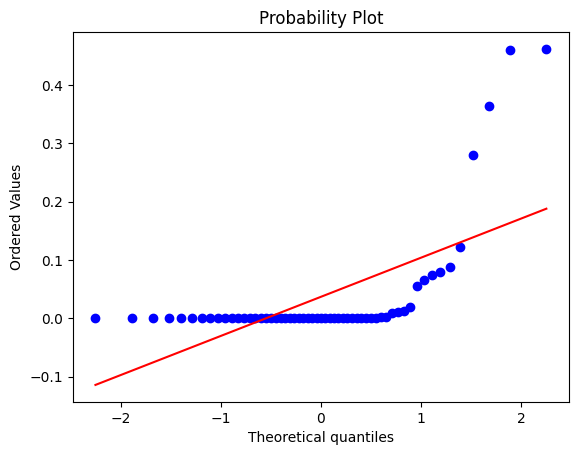

In [149]:
stats.probplot(x_train_scaled[0],dist="norm",plot=plt)
plt.show()

In [150]:
knn_euclidean = KNeighborsClassifier(n_neighbors=3,metric="euclidean")
knn_euclidean.fit(x_train_scaled,y_train)
start_time_euclidean = time.time()
y_pred_euclidiean = knn_euclidean.predict(x_test_scaled)
end_time_euclidean = time.time()
accuracy_euclidean = accuracy_score(y_test,y_pred_euclidiean)
time_euclidean = end_time_euclidean-start_time_euclidean
print(accuracy_euclidean)
print(time_euclidean)

0.8892508143322475
0.02255415916442871


Changes with euclidean

In [151]:
print("difference in accuracy = ",accuracy_euclidean-accuracy_general)
print("difference in time = ",time_euclidean-time_general)

difference in accuracy =  0.11183496199782839
difference in time =  0.017930269241333008


QUES 1 with manhattan

In [152]:
knn_manhattan = KNeighborsClassifier(n_neighbors=3,metric="manhattan")
knn_manhattan.fit(x_train_scaled,y_train)
start_time_manhattan = time.time()
y_pred_manhattan= knn_manhattan.predict(x_test_scaled)
end_time_manhattan = time.time()
accuracy_manhattan = accuracy_score(y_test,y_pred_manhattan)
time_manhattan = end_time_manhattan-start_time_manhattan
print(accuracy_manhattan)
print(time_manhattan)

0.8968512486427795
0.04434609413146973


changes with manhattan

In [153]:
print("difference in accuracy = ",accuracy_manhattan-accuracy_general)
print("differnce in time = ",time_manhattan-time_general)

difference in accuracy =  0.11943539630836042
differnce in time =  0.03972220420837402


Acuuracy of Rot Learner

In [154]:
knn_rot = KNeighborsClassifier(n_neighbors=1,metric="euclidean")
knn_rot.fit(x_train_scaled,y_train)
y_pred_rot = knn_rot.predict(x_test_scaled)
accuracy_rot = accuracy_score(y_test,y_pred_rot)
print(accuracy_rot)

0.8686210640608035


In [155]:
accuracy_check = 0 
loop_number = 0 
accuracies = []
for i in range(1,21):
    knn_loop = KNeighborsClassifier(n_neighbors=i,metric="euclidean")
    knn_loop.fit(x_train_scaled,y_train)
    y_pred_loop = knn_loop.predict(x_test_scaled)
    accuracy_loop = accuracy_score(y_test,y_pred_loop)
    accuracies.append(accuracy_loop)
    print(accuracy_loop)

    if(accuracy_loop>accuracy_check):
        accuracy_check= accuracy_loop
        loop_number = i 

print("best accuracy = ",accuracy_check)
print("best value of k is =",loop_number)


0.8686210640608035
0.8740499457111836
0.8892508143322475
0.8859934853420195
0.8925081433224755
0.8957654723127035
0.8914223669923995
0.8903365906623235
0.8903365906623235
0.8957654723127035
0.8990228013029316
0.8946796959826275
0.8990228013029316
0.8903365906623235
0.8935939196525515
0.8892508143322475
0.8979370249728555
0.8957654723127035
0.8946796959826275
0.8914223669923995
best accuracy =  0.8990228013029316
best value of k is = 11


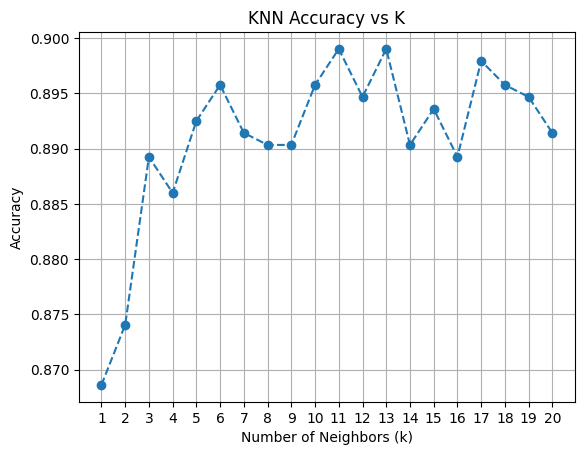

In [156]:
plt.plot(range(1, 21), accuracies, marker='o', linestyle='--')
plt.title("KNN Accuracy vs K")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()

0.8946796959826275
0.8914223669923995
0.8968512486427795
0.9001085776330076
0.9077090119435396
0.8979370249728555
0.9044516829533116
0.9066232356134636
0.9098805646036916
0.9066232356134636
0.9109663409337676
0.9022801302931596
0.9001085776330076
0.8946796959826275
0.8968512486427795
0.8957654723127035
0.9044516829533116
0.9011943539630836
0.8990228013029316
0.9001085776330076
best accuracy =  0.9109663409337676
best value of k is = 11


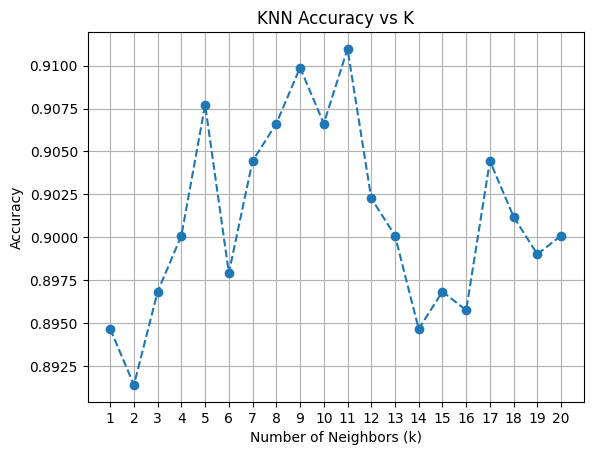

In [157]:
accuracy_check = 0 
loop_number = 0 
accuracies = []
for i in range(1,21):
    knn_loop = KNeighborsClassifier(n_neighbors=i,metric="manhattan")
    knn_loop.fit(x_train_scaled,y_train)
    y_pred_loop = knn_loop.predict(x_test_scaled)
    accuracy_loop = accuracy_score(y_test,y_pred_loop)
    accuracies.append(accuracy_loop)
    print(accuracy_loop)

    if(accuracy_loop>accuracy_check):
        accuracy_check= accuracy_loop
        loop_number = i 

print("best accuracy = ",accuracy_check)
print("best value of k is =",loop_number)

plt.plot(range(1, 21), accuracies, marker='o', linestyle='--')
plt.title("KNN Accuracy vs K")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()


Ques 7

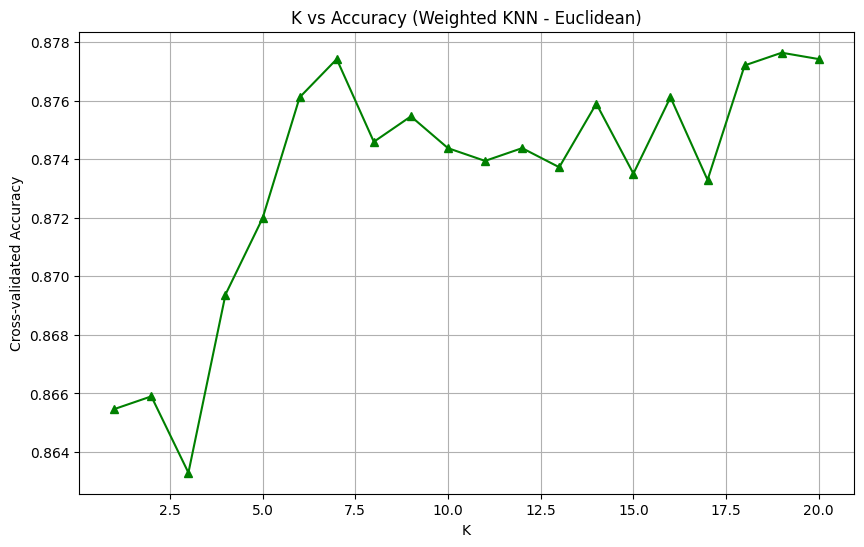

Best K (Weighted KNN): 19


In [161]:
from sklearn.model_selection import cross_val_score
minmax2= MinMaxScaler()
x_normalized = minmax2.fit_transform(x)
cv_scores_weighted = []

for k in range(1,21):
    knn_weighted = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
    scores = cross_val_score(knn_weighted, x_normalized, y, cv=5, scoring='accuracy')
    cv_scores_weighted.append(scores.mean())

plt.figure(figsize=(10,6))
plt.plot(range(1,21), cv_scores_weighted, marker='^', color='green')
plt.title('K vs Accuracy (Weighted KNN - Euclidean)')
plt.xlabel('K')
plt.ylabel('Cross-validated Accuracy')
plt.grid()
plt.show()

best_k_weighted = range(1,21)[np.argmax(cv_scores_weighted)]
print("Best K (Weighted KNN):", best_k_weighted)
